In [1]:
from collections import Counter
import argparse
import os
import json

import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
from pymatgen.io.cif import CifWriter

#added by Tsach


from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)


CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}
import sys

class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)

class RecEval(object):

    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        
        print(validity)

        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()

In [3]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

from cdvae.common.utils import PROJECT_ROOT
from cdvae.common.data_utils import (
    EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
    frac_to_cart_coords, min_distance_sqr_pbc)
from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

#added by Tsach
from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
#import Batch
from torch_geometric.data import Batch
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
torch.set_printoptions(threshold=50000) # use this if you want to print the entire tensor


import time
import argparse
import torch

from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
from types import SimpleNamespace
from torch_geometric.data import Batch
from torch_geometric.data.separate import separate

#import a library that allows you to reload a module
from importlib import reload

from eval_utils import load_model

all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

#my code 
list_of_idxs = []
list_of_batchs = []

import importlib 
import eval_utils
importlib.reload(eval_utils)
from eval_utils import load_model
model_path = Path("/home/gridsan/tmackey/hydra/singlerun/2024-01-11/augcag/")
model, test_loader, cfg = load_model(model_path, True)

loader = test_loader

the noise_sd is: 0.01
the noise_sd is: 0.01
constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/tmackey/cdvae/data/mp_20_aug_cag/test_20_any.csv
using existing graph file  /home/gridsan/tmackey/cdvae/data/mp_20_aug_cag/test_20_any.pt
no filter
using 9047 rows given a train_fraction of 1
[Errno 2] No such file or directory: '/home/gridsan/tmackey/cdvae/data/mp_20_aug_cag/test_xrd_peak_intensities_dict.pt'
time taken: 32.697235345840454
CrystDataModule(self.datasets={'train': {'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy train', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20_aug_cag/train.csv', 'prop': 'formation_energy_per_atom', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30, 'train_fraction': 1}, 'val': [{'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy val', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20_

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/torch_geometric/deprecation.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [4]:
model.to('cuda:0')

CDVAE(
  (simple_conv_net): SimpleConvNet(
    (conv_layers): Sequential(
      (0): Conv1d(1, 80, kernel_size=(100,), stride=(5,))
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Conv1d(80, 80, kernel_size=(50,), stride=(5,))
      (4): ReLU()
      (5): Dropout(p=0.3, inplace=False)
      (6): Conv1d(80, 80, kernel_size=(25,), stride=(2,))
      (7): ReLU()
      (8): Dropout(p=0.3, inplace=False)
    )
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (MLP): Sequential(
      (0): Linear(in_features=12160, out_features=2300, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=2300, out_features=1150, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.5, inplace=False)
      (6): Linear(in_features=1150, out_features=256, bias=True)
    )
  )
  (encoder): DimeNetPlusPlusWrap(
    (rbf): BesselBasisLayer(
      (envelope): Envelope()
    )
    (sbf): SphericalBasisLayer(
      (envelope): Envelope()
    )
    (em

In [5]:
ld_kwargs = SimpleNamespace(n_step_each=100,
                                step_lr=1e-4,
                                min_sigma=0,
                                save_traj=False,
                                disable_bar=False)

In [7]:
for idx, batch in enumerate(loader):
    print(idx)
    list_of_idxs.append(idx)
    list_of_batchs.append(batch)

idx = list_of_idxs[0]
batch = list_of_batchs[0]

def new_dataloader_batch_processor(batch): 
    batch_reserve = batch
    xrd_int = batch_reserve[1]
    xrd_loc = batch_reserve[2]
    atom_spec = batch_reserve[3]
    pv_xrd = batch_reserve[5]
    batch = batch[0]
    return batch_reserve, xrd_int, xrd_loc, atom_spec, batch, pv_xrd

batch_reserve, xrd_int, xrd_loc, atom_spec, batch, pv_xrd = new_dataloader_batch_processor(batch)
all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

batch_all_frac_coords = []
batch_all_atom_types = []
batch_frac_coords, batch_num_atoms, batch_atom_types = [], [], []
batch_lengths, batch_angles = [], []

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141


TypeError: conv1d(): argument 'input' (position 1) must be Tensor, not NoneType

In [15]:
pv_xrd = pv_xrd.to('cuda:0')

In [16]:
#wrecking the batch value to demonstrate decoding only from the xrd info
_, _, z = model.encode(None, xrd_int, xrd_loc, atom_spec, atom_spec, False, pv_xrd)

In [17]:
index = 10

In [18]:

#take only the first crystal to avoid issues with memory 
z = z[[index]]

self = model

num_atoms = batch.num_atoms[[index]]
num_atoms = num_atoms.to('cuda:0')

atom_spec = atom_spec[[index]]
atom_spec = atom_spec.to('cuda:0')

z = z.to('cuda:0')

force_num_atoms = True
gt_num_atoms = num_atoms if force_num_atoms else None

gt_atom_types = None

In [19]:
if index == 0: 
    crystal_range = range(min(0, np.cumsum(batch.num_atoms.cpu().numpy())[(index - 1)]), np.cumsum(batch.num_atoms.cpu().numpy())[index])
else: 
    crystal_range = range(np.cumsum(batch.num_atoms.cpu().numpy())[(index - 1)], np.cumsum(batch.num_atoms.cpu().numpy())[index])

In [20]:
#first step: create a ground truth crystal for comparison 

#get the lattice parameters and atom types and fractional coorinates for the first crystal 
gt_lengths = batch.lengths[[index]]
gt_angles = batch.angles[[index]]
gt_frac_coords = batch.frac_coords[[crystal_range]]
gt_types = batch.atom_types[[crystal_range]]

lengths = gt_lengths.numpy().flatten()
angles = gt_angles.numpy().flatten()

# Initialize the Lattice
lattice = Lattice.from_parameters(lengths[0], lengths[1], lengths[2], angles[0], angles[1], angles[2])

In [21]:
len(gt_types)

20

In [22]:
gt_tructure = Structure(lattice, species=gt_types, coords=gt_frac_coords, coords_are_cartesian=False)

In [23]:
gt_tructure

Structure Summary
Lattice
    abc : 5.456483718977095 5.55056905746461 7.753438949584961
 angles : 90.00000250447815 90.07083156144775 89.99999749242761
 volume : 234.82504473511528
      A : 5.456479549407959 0.0 -0.006745543330907822
      B : 2.4262308784273046e-07 5.5505690574646 -2.4262308784273046e-07
      C : 0.0 0.0 7.753438949584961
    pbc : True True True
PeriodicSite: Na (5.432, 1.255, 5.809) [0.9956, 0.2261, 0.7501]
PeriodicSite: Na (2.704, 4.295, 1.936) [0.4956, 0.7739, 0.2501]
PeriodicSite: Ca (2.798, 3.913, 5.812) [0.5128, 0.705, 0.75]
PeriodicSite: Ca (0.06994, 1.638, 1.938) [0.01282, 0.295, 0.25]
PeriodicSite: Ta (2.761, 1.354, -0.001676) [0.506, 0.244, 0.000224]
PeriodicSite: Ta (0.03259, 4.196, 3.878) [0.005972, 0.756, 0.5002]
PeriodicSite: Ti (2.763, 1.36, 3.897) [0.5064, 0.245, 0.503]
PeriodicSite: Ti (0.03479, 4.191, 0.02356) [0.006376, 0.755, 0.003044]
PeriodicSite: O (5.048, 4.065, 1.917) [0.9252, 0.7323, 0.2481]
PeriodicSite: O (4.239, 2.608, 4.165) [0.7768, 

In [24]:
gt_elements_input=atom_spec

In [25]:
if ld_kwargs.save_traj:
    all_frac_coords = []
    all_pred_cart_coord_diff = []
    all_noise_cart = []
    all_atom_types = []

# obtain key stats.
if not self.use_composition_constraint: 
    gt_elements_input = None

num_atoms, _, lengths, angles, composition_per_atom = self.decode_stats(
    z, gt_num_atoms, gt_elements=gt_elements_input)

if gt_num_atoms is not None:
    num_atoms = gt_num_atoms

composition_per_atom = F.softmax(composition_per_atom, dim=-1)

if gt_atom_types is None:
    composition_per_atom = composition_per_atom.cuda(0)
    num_atoms = num_atoms.cuda(0)
    cur_atom_types = self.sample_composition(
        composition_per_atom, num_atoms)
else:
    cur_atom_types = gt_atom_types

# init coords.
cur_frac_coords = torch.rand((num_atoms.sum(), 3), device=z.device)

/home/gridsan/tmackey/cdvae/cdvae/common/data_utils.py:627: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)


In [26]:
cur_atom_types

tensor([ 8, 22,  8,  8,  8,  8, 11, 20, 73,  8, 11,  8, 22, 73, 20, 22,  8,  8,
        73,  8], device='cuda:0')

In [27]:
len(cur_atom_types)

20

In [28]:
gt_num_atoms

tensor([20], device='cuda:0')

In [29]:
cur_frac_coords

tensor([[0.2988, 0.1346, 0.7529],
        [0.0550, 0.4530, 0.3068],
        [0.7784, 0.0287, 0.6342],
        [0.3107, 0.4152, 0.4541],
        [0.1550, 0.3213, 0.0322],
        [0.8088, 0.4117, 0.1607],
        [0.5024, 0.5045, 0.6979],
        [0.9134, 0.6360, 0.7877],
        [0.1966, 0.4629, 0.1646],
        [0.6870, 0.8712, 0.6599],
        [0.2868, 0.0876, 0.4158],
        [0.6133, 0.0953, 0.4241],
        [0.4261, 0.6145, 0.3759],
        [0.4838, 0.5895, 0.1096],
        [0.6109, 0.4258, 0.2445],
        [0.7883, 0.4363, 0.5459],
        [0.0159, 0.1875, 0.0700],
        [0.7579, 0.9133, 0.1114],
        [0.1972, 0.4874, 0.3999],
        [0.2675, 0.1215, 0.6248]], device='cuda:0')

In [30]:
class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)

In [31]:
lengths_for_lattice = lengths.cpu().numpy().flatten()
angles_for_lattice = angles.cpu().numpy().flatten()

In [32]:
lattice = Lattice.from_parameters(lengths_for_lattice[0], lengths_for_lattice[1], lengths_for_lattice[2], 
                                  angles_for_lattice[0], angles_for_lattice[1], angles_for_lattice[2])

In [33]:
lattice

Lattice
    abc : 5.631434297405417 5.696848290403259 8.006399154663086
 angles : 90.31871280298874 90.39853724262227 90.40781472812243
 volume : 256.83994374138933
      A : 5.631298065185547 0.0 -0.03917074203491211
      B : -0.04076957702636719 5.6966142654418945 -0.031689055263996124
      C : 0.0 0.0 8.006399154663086
    pbc : True True True

In [34]:
sigma = self.sigmas[0]
step_size = ld_kwargs.step_lr * (sigma / self.sigmas[-1]) ** 2

In [35]:
noise_cart = torch.randn_like(
    cur_frac_coords) * torch.sqrt(step_size * 2)
pred_cart_coord_diff, pred_atom_types = self.decoder(
    z, cur_frac_coords, cur_atom_types, num_atoms, lengths, angles, gt_elements=gt_elements_input)

In [36]:
cur_cart_coords = frac_to_cart_coords(
    cur_frac_coords, lengths, angles, num_atoms)
pred_cart_coord_diff = pred_cart_coord_diff / sigma
cur_cart_coords = cur_cart_coords + step_size * pred_cart_coord_diff + noise_cart
cur_frac_coords = cart_to_frac_coords(
    cur_cart_coords, lengths, angles, num_atoms)

In [37]:
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
torch.set_printoptions(threshold=50000) # use this if you want to print the entire tensor
import matplotlib.pyplot as plt

In [38]:
def get_structure(cur_frac_coords, pred_atom_types, lattice, cur_atom_types = None): 
    cur_frac_coords_for_structure = cur_frac_coords.detach().cpu().numpy()
    if cur_atom_types == None:
        cur_atom_types = torch.argmax(pred_atom_types, dim=1) + 1
    pred_atom_types_for_structure = cur_atom_types.detach().cpu().numpy().flatten()
    pred_structure = Structure(lattice, species=pred_atom_types_for_structure, coords=cur_frac_coords_for_structure, coords_are_cartesian=False)
    return pred_structure

In [39]:
pred_structure = get_structure(cur_frac_coords, pred_atom_types, lattice)

In [40]:
#let's pull out the diffraction patterns ahead of time 
def simulate_xrd(peak_locations, peak_intensities, lower_bound = 5, upper_bound = 75, dimensions = 200):
    interval =  (upper_bound - lower_bound)/dimensions
    sim_positions = np.arange(lower_bound, upper_bound, interval)
    # Create an empty intensity array for the simulation
    sim_intensities = np.zeros_like(sim_positions)
    
    # Loop over all simulated positions
    for i, pos in enumerate(sim_positions):
        # Find peak locations within 0.25° of the current simulated position
        close_peaks = [(loc, intensity) for loc, intensity in zip(peak_locations, peak_intensities) if abs(loc - pos) <= interval/2]
        
        # If there are close peaks, sum the intensities among those peaks
        if close_peaks:
            intensities = np.array([intensity for loc, intensity in close_peaks])
            sim_intensities[i] = np.sum(intensities)
    
    sim_intensities = 100*sim_intensities / max(sim_intensities)
    
    return sim_intensities

In [41]:
def calc_and_compare_xrds(structure, structure2, wavelength='CuKa', annotate_peaks=False, 
                          overlay = True, plot = False, plot_peaks = False,
                         startpoint = 0.5, endpoint = 90, num_intervals = 1000):
    
    """
    Plot the XRD pattern of a given structure using PyMatgen.

    :param structure: Pymatgen Structure object
    :param wavelength: Wavelength of the X-rays. Defaults to 'CuKa'.
    :param annotate_peaks: Annotate the peaks with hkl values if True.
    """
 
    #set params
    

    # Get the diffraction pattern
    pattern = xrd_calculator.get_pattern(structure)

    two_theta = pattern.x
    intensity = pattern.y

    
    # Simulate the XRD pattern
    sim_intensities = simulate_xrd(two_theta, intensity, startpoint, endpoint, num_intervals)
    domain = np.linspace(startpoint, endpoint, num_intervals, dtype=int)
    
    #repeat for structure 2
    pattern2 = xrd_calculator.get_pattern(structure2)

    two_theta2 = pattern2.x
    intensity2 = pattern2.y

    # Simulate the XRD pattern
    sim_intensities = simulate_xrd(two_theta, intensity,startpoint, endpoint, num_intervals)
    domain = np.linspace(startpoint, endpoint, num_intervals, dtype=int)
    
    #repeat for structure2
    sim_intensities2 = simulate_xrd(two_theta2, intensity2, startpoint, endpoint, num_intervals)
    
    if plot: 
        plt.figure(figsize=(12, 6))

        # Plot the simulated pattern
        plt.plot(domain, sim_intensities, label='Simulated XRD 1')
        if overlay: 
            plt.plot(domain, sim_intensities2, label='Simulated XRD 2')
        #add support later for not overlay

        # Overlay the peaks as a stem plot
        if plot_peaks:
            plt.stem(two_theta, intensity, linefmt='C3-', markerfmt='C3o', basefmt=' ', use_line_collection=True, label='XRD Peaks')

        plt.title(f"XRD Pattern for {structure2.formula}")
        plt.xlabel("2θ [degrees]")
        plt.ylabel("Intensity [Arbitrary Units]")
        plt.legend()

        plt.show()
    
    return two_theta, intensity, sim_intensities, two_theta2, intensity2, sim_intensities2

In [42]:
def cosine_similarity(array1, array2):
    """
    Calculate the cosine similarity between two numpy arrays.

    :param array1: First numpy array
    :param array2: Second numpy array
    :return: Cosine similarity as a float
    """
    dot_product = np.dot(array1, array2)
    norm_array1 = np.linalg.norm(array1)
    norm_array2 = np.linalg.norm(array2)

    if norm_array1 == 0 or norm_array2 == 0:
        # Handling the case where one or both vectors are zero vectors
        return 0.0
    
    cosine_sim = dot_product / (norm_array1 * norm_array2)
    return cosine_sim

In [43]:
import numpy as np

In [44]:
def calc_mse(array1, array2, temperature = 1):
    """
    Calculate the Mean Squared Error (MSE) between two numpy arrays.

    :param array1: First numpy array
    :param array2: Second numpy array
    :return: Mean Squared Error as a float
    """
    if array1.shape != array2.shape:
        raise ValueError("Arrays must have the same shape")

    mse = np.mean((array1 - array2) ** 2)
    
    
    return mse

In [45]:
import torch
import random

def randomly_change_fraction_tensor(tensor, fraction):
    """
    Randomly change a fraction of the numbers in a 1D PyTorch tensor to other numbers already in the tensor.

    :param tensor: 1D PyTorch tensor.
    :param fraction: Fraction of numbers to be changed.
    :return: Tensor with some numbers changed.
    """
    if tensor.nelement() == 0:
        raise ValueError("The tensor is empty.")

    tensor_length = tensor.size(0)
    num_elements_to_change = int(round(fraction * tensor_length))

    if num_elements_to_change!=0:
        # Ensure the divisor of tensor length
        while tensor_length % num_elements_to_change != 0:
            num_elements_to_change -= 1

        # Indices of elements to change
        indices_to_change = random.sample(range(tensor_length), num_elements_to_change)

        # Changing the elements
        for idx in indices_to_change:
            # Pick a random element from the tensor that's not the current one
            possible_values = tensor[tensor != tensor[idx]]
            if possible_values.nelement() == 0:
                continue  # Skip if no alternative values are found
            new_val = possible_values[random.randint(0, possible_values.size(0) - 1)]
            tensor[idx] = new_val

    return tensor

# Example usage
tensor = torch.tensor([1, 2, 5, 5, 52])
fraction_to_change = 0.4
result = randomly_change_fraction_tensor(tensor, fraction_to_change)
print(result)


tensor([1, 2, 5, 5, 1])


In [46]:
#first step: create a ground truth crystal for comparison 

#get the lattice parameters and atom types and fractional coorinates for the first crystal 
gt_lengths = batch.lengths[[index]]
gt_angles = batch.angles[[index]]
gt_frac_coords = batch.frac_coords[[crystal_range]]
gt_types = batch.atom_types[[crystal_range]]

lengths = gt_lengths.numpy().flatten()
angles = gt_angles.numpy().flatten()

# Initialize the Lattice
lattice = Lattice.from_parameters(lengths[0], lengths[1], lengths[2], angles[0], angles[1], angles[2])

lengths = gt_lengths.to(z.device)
angles = gt_angles.to(z.device)


In [47]:
len(gt_types)

20

In [48]:
num_atoms

tensor([20], device='cuda:0')

In [49]:
pred_structure

Structure Summary
Lattice
    abc : 5.631434297405417 5.696848290403259 8.006399154663086
 angles : 90.31871280298874 90.39853724262227 90.40781472812243
 volume : 256.83994374138933
      A : 5.631298065185547 0.0 -0.03917074203491211
      B : -0.04076957702636719 5.6966142654418945 -0.031689055263996124
      C : 0.0 0.0 8.006399154663086
    pbc : True True True
PeriodicSite: O (4.458, 2.795, 0.3508) [0.7951, 0.4906, 0.04965]
PeriodicSite: Ti (0.5766, 2.717, 6.773) [0.1058, 0.477, 0.8484]
PeriodicSite: O (0.1705, 2.736, 4.123) [0.03375, 0.4803, 0.517]
PeriodicSite: O (0.8083, 1.314, 0.4385) [0.1452, 0.2306, 0.05639]
PeriodicSite: O (3.234, 1.756, 2.133) [0.5765, 0.3083, 0.2704]
PeriodicSite: O (3.043, 1.887, 1.827) [0.5428, 0.3312, 0.2322]
PeriodicSite: O (2.524, 3.689, 3.566) [0.4529, 0.6477, 0.4502]
PeriodicSite: O (3.411, 0.3703, 4.02) [0.6062, 0.06501, 0.5053]
PeriodicSite: Ta (2.547, 2.849, 2.228) [0.456, 0.5002, 0.2825]
PeriodicSite: O (2.269, 1.055, 3.567) [0.4043, 0.1853, 0

In [50]:
gt_atom_types = gt_types
cur_atom_types = gt_atom_types

In [51]:
cur_atom_types = cur_atom_types.to(z.device)
cur_atom_types

tensor([11, 11, 20, 20, 73, 73, 22, 22,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
         8,  8], device='cuda:0')

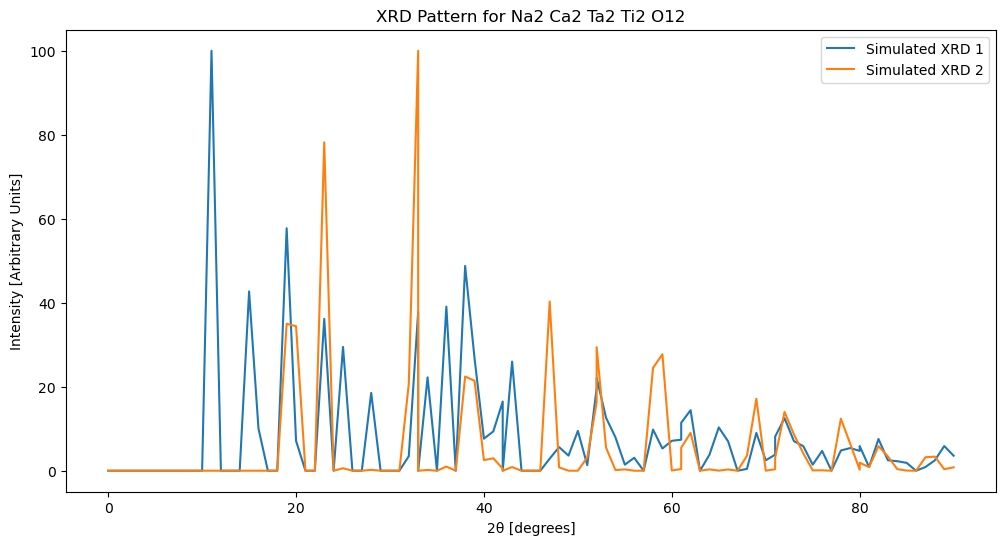

In [82]:
time = 0
ratio = 0 
original_val = 1000000
ld_kwargs.n_step_each = 100
kmax = self.sigmas.size(0) * ld_kwargs.n_step_each
num_intervals = 100
cur_frac_coords = torch.rand((num_atoms.sum(), 3), device=z.device) #re-randomize
pred_structure = get_structure(cur_frac_coords, None, lattice, cur_atom_types = cur_atom_types)
_, _, pred_dsi, _, _, gt_dsi = calc_and_compare_xrds(pred_structure, gt_tructure, plot = True, num_intervals = num_intervals )
temp_scaler = 1
target = "mse"
override = False

curr_crystal_dict = {'frac_coords': cur_cart_coords.detach().cpu(),
                             'atom_types': cur_atom_types.detach().cpu(),
                             'lengths': lengths[0].detach().cpu(),
                             'angles': angles[0].detach().cpu()}

curr_crystal_object = Crystal(curr_crystal_dict)
curr_crystal_valid = curr_crystal_object.valid

In [83]:
curr_crystal_valid

True

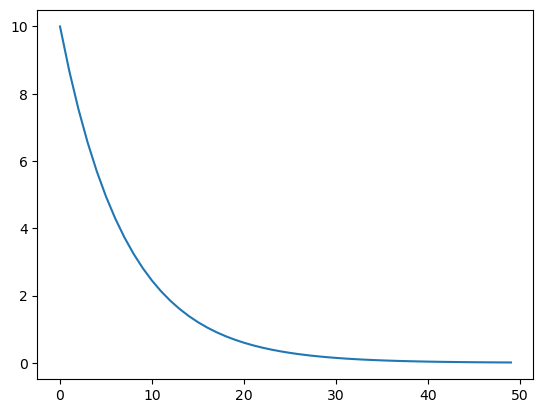

In [84]:
plt.plot(self.sigmas.detach().cpu().numpy())

In [85]:
ld_kwargs.min_sigma

0

In [86]:
# annealed langevin dynamics.
for sigma in tqdm(self.sigmas, total=self.sigmas.size(0), disable=ld_kwargs.disable_bar):
    if sigma < ld_kwargs.min_sigma:
        break
    step_size = ld_kwargs.step_lr * (sigma / self.sigmas[-1]) ** 2
    
    for step in range(ld_kwargs.n_step_each):
        
        temperature = 1 - (time)/kmax
        noise_cart = torch.randn_like(
            cur_frac_coords) * torch.sqrt(step_size * 2)
                
        pred_cart_coord_diff, pred_atom_types = self.decoder(
            z, cur_frac_coords, cur_atom_types, num_atoms, lengths, angles, gt_elements=gt_elements_input)
        cur_cart_coords = frac_to_cart_coords(
            cur_frac_coords, lengths, angles, num_atoms)
        pred_cart_coord_diff = pred_cart_coord_diff / sigma
        
        candidate_cart_coords = cur_cart_coords + step_size * pred_cart_coord_diff + noise_cart
        candidate_frac_coords = cart_to_frac_coords(candidate_cart_coords, lengths, angles, num_atoms)
        
        candidate_atom_types = torch.argmax(pred_atom_types, dim=1) + 1
        
        if sigma > 0.1:
            cur_cart_coords = cur_cart_coords + step_size * pred_cart_coord_diff + noise_cart
            cur_frac_coords = cart_to_frac_coords(cur_cart_coords, lengths, angles, num_atoms)

            if gt_atom_types is None:
                cur_atom_types = candidate_atom_types
        else:
            try: 
                #ratio section 
                pred_structure = get_structure(candidate_frac_coords, pred_atom_types, lattice)
                _, _, pred_dsi, _, _, _ = calc_and_compare_xrds(pred_structure, gt_tructure, num_intervals= num_intervals)
                cosine_sim = -1 * cosine_similarity(pred_dsi, gt_dsi)
                mse = calc_mse(pred_dsi, gt_dsi)
                effective_temperature = temp_scaler*temperature

                if target == "cosine_sim": 
                    new_val = cosine_sim
                else:
                    new_val = mse

                ratio = np.exp((original_val - new_val)/(temp_scaler*effective_temperature))

                pred_atom_types_for_dict = torch.argmax(pred_atom_types, dim=1) + 1
                pred_crystal_dict = {'frac_coords': candidate_frac_coords.detach().cpu(),
                                 'atom_types': pred_atom_types_for_dict.detach().cpu(),
                                 'lengths': lengths[0].detach().cpu(),
                                 'angles': angles[0].detach().cpu()}

                pred_crystal_object = Crystal(pred_crystal_dict)

                if (ratio > np.random.uniform(0, 1) or override or (not curr_crystal_valid)):
                    if pred_crystal_object.valid or (not curr_crystal_valid): 
                        print('candidate accepted with mse {}, ratio {}, temperature {}, cosine_sim {}'.format(
                            mse, ratio, effective_temperature, cosine_sim))

                        cur_cart_coords = cur_cart_coords + step_size * pred_cart_coord_diff + noise_cart
                        cur_frac_coords = cart_to_frac_coords(cur_cart_coords, lengths, angles, num_atoms)

                        if gt_atom_types is None:
                            cur_atom_types = candidate_atom_types

                        #original_val = cosine_sim
                        original_val = new_val

                        curr_crystal_valid = pred_crystal_object.valid 

                        #_, _, _, _, _, _ = calc_and_compare_xrds(pred_structure, gt_tructure, plot=True,  num_intervals= 100)
                    else: 
                        print('candidate rejected not valid')

                else: 
                    print('candidate rejected with mse {}, ratio {}, temperature {}, cosine_sim {}'.format(
                            mse, ratio, effective_temperature, cosine_sim))

                time += 1

                if ld_kwargs.save_traj:
                    all_frac_coords.append(cur_frac_coords)
                    all_pred_cart_coord_diff.append(
                        step_size * pred_cart_coord_diff)
                    all_noise_cart.append(noise_cart)
                    all_atom_types.append(cur_atom_types)
            except Exception as e: 
                print(e)
                print('err')
                continue

output_dict = {'num_atoms': num_atoms, 'lengths': lengths, 'angles': angles,
            'frac_coords': cur_frac_coords, 'atom_types': cur_atom_types,
            'is_traj': False}

if ld_kwargs.save_traj:
    output_dict.update(dict(
        all_frac_coords=torch.stack(all_frac_coords, dim=0),
        all_atom_types=torch.stack(all_atom_types, dim=0),
        all_pred_cart_coord_diff=torch.stack(
            all_pred_cart_coord_diff, dim=0),
        all_noise_cart=torch.stack(all_noise_cart, dim=0),
        is_traj=True))

 10%|█         | 5/50 [00:14<02:07,  2.83s/it]


RuntimeError: CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 31.74 GiB total capacity; 29.19 GiB already allocated; 4.88 MiB free; 29.30 GiB reserved in total by PyTorch)

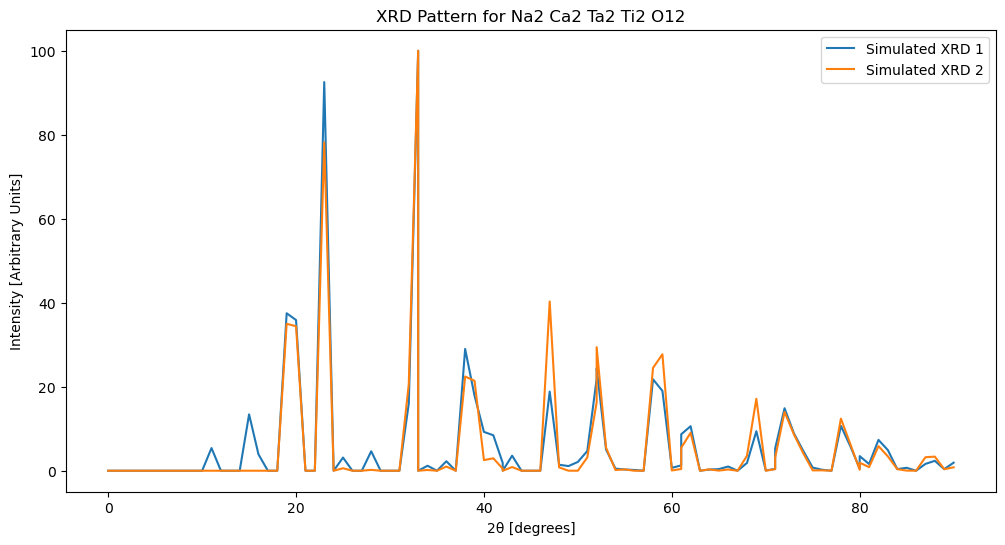

In [58]:
curr_structure = get_structure(cur_frac_coords, pred_atom_types, lattice)
_, _, pred_dsi, _, _, gt_dsi = calc_and_compare_xrds(curr_structure, gt_tructure, plot = True, num_intervals = num_intervals )
mse = calc_mse(pred_dsi, gt_dsi)

In [59]:
mse

13.37637534579448

In [60]:
#get the lattice parameters and atom types and fractional coorinates for the first crystal 
gt_lengths = batch.lengths[[index]]
gt_angles = batch.angles[[index]]
gt_frac_coords = batch.frac_coords[[crystal_range]]
gt_types = batch.atom_types[[crystal_range]]

In [61]:
gt_crystal_dict = {'frac_coords': gt_frac_coords,
       'atom_types': gt_types,
       'lengths': gt_lengths[0],
       'angles': gt_angles[0]}

In [62]:
gt_crystal_dict

{'frac_coords': tensor([[9.9559e-01, 2.2613e-01, 7.5007e-01],
         [4.9559e-01, 7.7387e-01, 2.5007e-01],
         [5.1282e-01, 7.0496e-01, 7.4999e-01],
         [1.2817e-02, 2.9504e-01, 2.4999e-01],
         [5.0597e-01, 2.4397e-01, 2.2400e-04],
         [5.9720e-03, 7.5603e-01, 5.0022e-01],
         [5.0638e-01, 2.4498e-01, 5.0304e-01],
         [6.3760e-03, 7.5502e-01, 3.0440e-03],
         [9.2521e-01, 7.3230e-01, 2.4805e-01],
         [7.7685e-01, 4.6989e-01, 5.3786e-01],
         [7.8012e-01, 4.6902e-01, 9.6101e-01],
         [7.0607e-01, 9.6225e-01, 5.4319e-01],
         [7.0816e-01, 9.5731e-01, 9.5564e-01],
         [5.8283e-01, 2.3327e-01, 2.5091e-01],
         [4.2521e-01, 2.6770e-01, 7.4805e-01],
         [2.7685e-01, 5.3011e-01, 3.7855e-02],
         [2.8012e-01, 5.3098e-01, 4.6101e-01],
         [2.0607e-01, 3.7748e-02, 4.3190e-02],
         [2.0817e-01, 4.2690e-02, 4.5564e-01],
         [8.2832e-02, 7.6673e-01, 7.5091e-01]]),
 'atom_types': tensor([11, 11, 20, 20, 73, 

In [63]:
gt_crystal_object = Crystal(gt_crystal_dict)

In [64]:
curr_structure

Structure Summary
Lattice
    abc : 5.456483718977095 5.55056905746461 7.753438949584961
 angles : 90.00000250447815 90.07083156144775 89.99999749242761
 volume : 234.82504473511528
      A : 5.456479549407959 0.0 -0.006745543330907822
      B : 2.4262308784273046e-07 5.5505690574646 -2.4262308784273046e-07
      C : 0.0 0.0 7.753438949584961
    pbc : True True True
PeriodicSite: Na (3.746, 1.457, 4.646) [0.6866, 0.2625, 0.5998]
PeriodicSite: Na (3.982, 1.768, 0.9024) [0.7298, 0.3185, 0.117]
PeriodicSite: Ca (0.2291, 1.112, 2.881) [0.04199, 0.2004, 0.3716]
PeriodicSite: Ca (4.387, 1.7, 4.71) [0.8039, 0.3062, 0.6082]
PeriodicSite: Ta (1.407, 1.612, 6.544) [0.2579, 0.2905, 0.8442]
PeriodicSite: Ta (4.13, 4.373, 2.698) [0.757, 0.7879, 0.3486]
PeriodicSite: Ti (1.31, 1.732, 2.545) [0.24, 0.312, 0.3284]
PeriodicSite: Ti (3.941, 3.912, 6.454) [0.7223, 0.7048, 0.8331]
PeriodicSite: O (5.144, 5.255, 3.268) [0.9427, 0.9468, 0.4224]
PeriodicSite: O (1.736, 5.145, 7.61) [0.3181, 0.9269, 0.9818]


In [65]:
pred_crystal_dict = {'frac_coords': cur_frac_coords.detach().cpu(),
       'atom_types': cur_atom_types.detach().cpu(),
       'lengths': lengths[0].detach().cpu(),
       'angles': angles[0].detach().cpu()}

In [66]:
pred_crystal_dict

{'frac_coords': tensor([[0.6866, 0.2625, 0.5998],
         [0.7298, 0.3185, 0.1170],
         [0.0420, 0.2004, 0.3716],
         [0.8039, 0.3062, 0.6082],
         [0.2579, 0.2905, 0.8442],
         [0.7570, 0.7879, 0.3486],
         [0.2400, 0.3120, 0.3284],
         [0.7223, 0.7048, 0.8331],
         [0.9427, 0.9468, 0.4224],
         [0.3181, 0.9269, 0.9818],
         [0.9708, 0.9795, 0.8028],
         [0.6287, 0.8676, 0.0076],
         [0.0088, 0.5069, 0.7235],
         [0.0973, 0.0693, 0.4232],
         [0.1480, 0.9665, 0.2257],
         [0.0474, 0.2254, 0.6665],
         [0.5378, 0.3233, 0.8626],
         [0.2003, 0.0430, 0.2597],
         [0.5265, 0.0755, 0.7356],
         [0.1821, 0.0574, 0.7506]]),
 'atom_types': tensor([11, 11, 20, 20, 73, 73, 22, 22,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
          8,  8]),
 'lengths': tensor([5.4565, 5.5506, 7.7534]),
 'angles': tensor([90.0000, 90.0708, 90.0000])}

In [67]:
pred_crystal_object = Crystal(pred_crystal_dict)

In [68]:
pred_crys = [pred_crystal_object]
gt_crys = [gt_crystal_object]

In [69]:
rec_evaluator = RecEval(pred_crys, gt_crys)
recon_metrics = rec_evaluator.get_metrics()

[True]


100%|██████████| 1/1 [00:00<00:00, 95.17it/s]
/state/partition1/slurm_tmp/24775323.0.0/ipykernel_3388719/4011252058.py:180: RuntimeWarning: Mean of empty slice.
  mean_rms_dist = rms_dists[rms_dists != None].mean()
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/numpy/core/_methods.py:194: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


In [70]:
recon_metrics

{'match_rate': 0.0,
 'rms_dist': nan,
 'diff_dist': None,
 'rmsd_values': array([None], dtype=object)}